# Notebook 03 — O Nordeste e suas Contradições

**Projeto:** Mapa da Inseminação Artificial no Brasil  
**Autor:** Mateus Martins — Médico Veterinário

O Nordeste pecuário me intriga. Tem 30 milhões de bovinos, mas a adoção de IA 
vai de 79,5% (Alagoas) a 5,2% (Piauí). Neste notebook investigo por que 
Alagoas é outlier, qual o potencial do MATOPIBA, quais as barreiras reais
e quanto dinheiro está sendo deixado na mesa.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
AZUL = '#2E75B6'
VERDE = '#548235'
VERMELHO = '#C0504D'
AMARELO = '#E6A817'
CINZA = '#7F7F7F'
LARANJA = '#ED7D31'
plt.rcParams['figure.dpi'] = 150

df = pd.read_csv('data/processed/dataset_ia_brasil.csv')
asbia_brasil = pd.read_csv('data/raw/asbia_dados_compilados.csv')

ne_states = ['MA', 'PI', 'CE', 'RN', 'PB', 'PE', 'AL', 'SE', 'BA']
df_ne = df[df['sigla_uf'].isin(ne_states)].copy()

print(f'Nordeste: {len(df_ne)} estados')
print(f'Rebanho total NE: {df_ne["rebanho"].sum()/1e6:.1f}M cabeças')
print(f'Fêmeas estimadas NE: {df_ne["femeas_estimadas"].sum()/1e6:.1f}M')

Nordeste: 9 estados
Rebanho total NE: 32.8M cabeças
Fêmeas estimadas NE: 18.0M


## 1. Por que Alagoas é Outlier?

Alagoas com 79,5% de fêmeas inseminadas (corte) é o dado mais contraintuitivo
deste estudo. É o segundo lugar nacional, atrás apenas de Santa Catarina.
Um estado pequeno, do Nordeste, batendo todo o Centro-Oeste.

Vamos investigar os possíveis motivos.

Comparação: Alagoas vs estados vizinhos
BA: Rebanho 12.1M | Corte 18.5% | Leite 6.5%
PE: Rebanho 2.4M | Corte 12.5% | Leite 7.0%
AL: Rebanho 1.4M | Corte 79.5% | Leite 8.5%
SE: Rebanho 1.3M | Corte 15.8% | Leite 5.0%


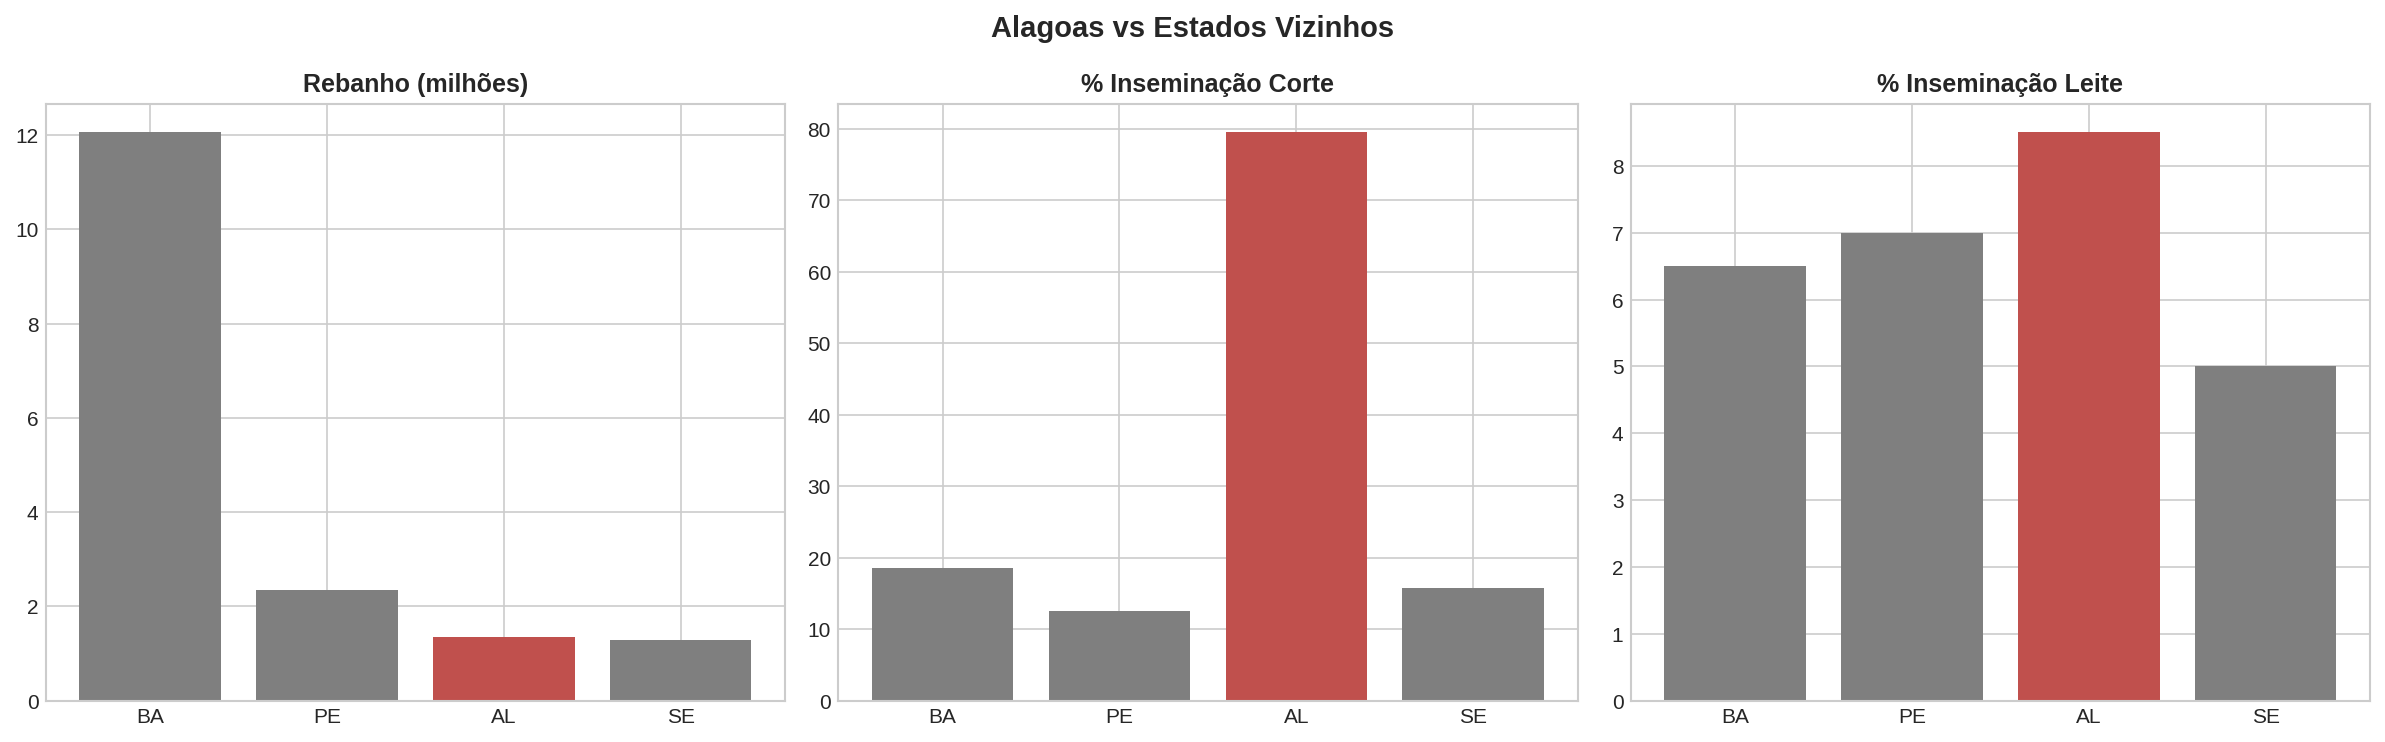

In [2]:
# Comparação AL vs vizinhos
vizinhos = ['AL', 'SE', 'PE', 'BA']
df_viz = df[df['sigla_uf'].isin(vizinhos)].copy()

print('Comparação: Alagoas vs estados vizinhos')
print('='*60)
for _, row in df_viz.iterrows():
    print(f"{row['sigla_uf']}: Rebanho {row['rebanho']/1e6:.1f}M | "
          f"Corte {row['pct_femeas_inseminadas_corte']:.1f}% | "
          f"Leite {row['pct_femeas_inseminadas_leite']:.1f}%")

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Rebanho
axes[0].bar(df_viz['sigla_uf'], df_viz['rebanho']/1e6, color=[VERMELHO if uf == 'AL' else CINZA for uf in df_viz['sigla_uf']])
axes[0].set_title('Rebanho (milhões)', fontweight='bold')

# % Inseminação corte
axes[1].bar(df_viz['sigla_uf'], df_viz['pct_femeas_inseminadas_corte'], 
            color=[VERMELHO if uf == 'AL' else CINZA for uf in df_viz['sigla_uf']])
axes[1].set_title('% Inseminação Corte', fontweight='bold')

# % Inseminação leite
axes[2].bar(df_viz['sigla_uf'], df_viz['pct_femeas_inseminadas_leite'],
            color=[VERMELHO if uf == 'AL' else CINZA for uf in df_viz['sigla_uf']])
axes[2].set_title('% Inseminação Leite', fontweight='bold')

fig.suptitle('Alagoas vs Estados Vizinhos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Hipóteses para o caso Alagoas

1. **Rebanho pequeno** (~1,35M cabeças): mais fácil atingir % alta. Uma central de 
   inseminação cobre uma proporção grande do rebanho.

2. **Programas estaduais de incentivo**: AL teve programas de melhoria genética do 
   rebanho leiteiro com subsídio para inseminação.

3. **Proximidade de centrais de sêmen**: PE, SE e BA têm centrais da CRV, Alta 
   Genetics e ABS que atendem AL.

4. **Perfil do rebanho**: alta proporção de gado leiteiro/dupla aptidão 
   (Girolando), que historicamente usa mais IA que gado estritamente de corte.

5. **Fator escala**: quando o denominador é pequeno, poucos programas de IA 
   conseguem mover o percentual significativamente.

**Nota de cautela**: o dado de 79,5% pode refletir em parte a metodologia do 
INDEX ASBIA — se as vendas de sêmen no estado são altas relativas ao rebanho, 
o % calculado sobe. Não significa necessariamente que 79,5% das vacas foram 
efetivamente inseminadas, pode haver re-inseminações contadas.

## 2. MATOPIBA — A Próxima Fronteira Reprodutiva

O MATOPIBA (Maranhão, Tocantins, Piauí, Bahia — área de cerrado) é a nova 
fronteira agrícola do Brasil. A pecuária cresceu junto com a soja, mas a 
adoção de tecnologia reprodutiva ainda é baixa.

É o equivalente ao que o Centro-Oeste era nos anos 2000 para a IATF.

MATOPIBA vs Centro-Oeste

MATOPIBA:
  Rebanho total: 31.9M
  % IA corte (média): 11.6%
  Fêmeas não inseminadas: 15.2M

Centro-Oeste:
  Rebanho total: 78.5M
  % IA corte (média): 27.4%
  Fêmeas não inseminadas: 31.9M


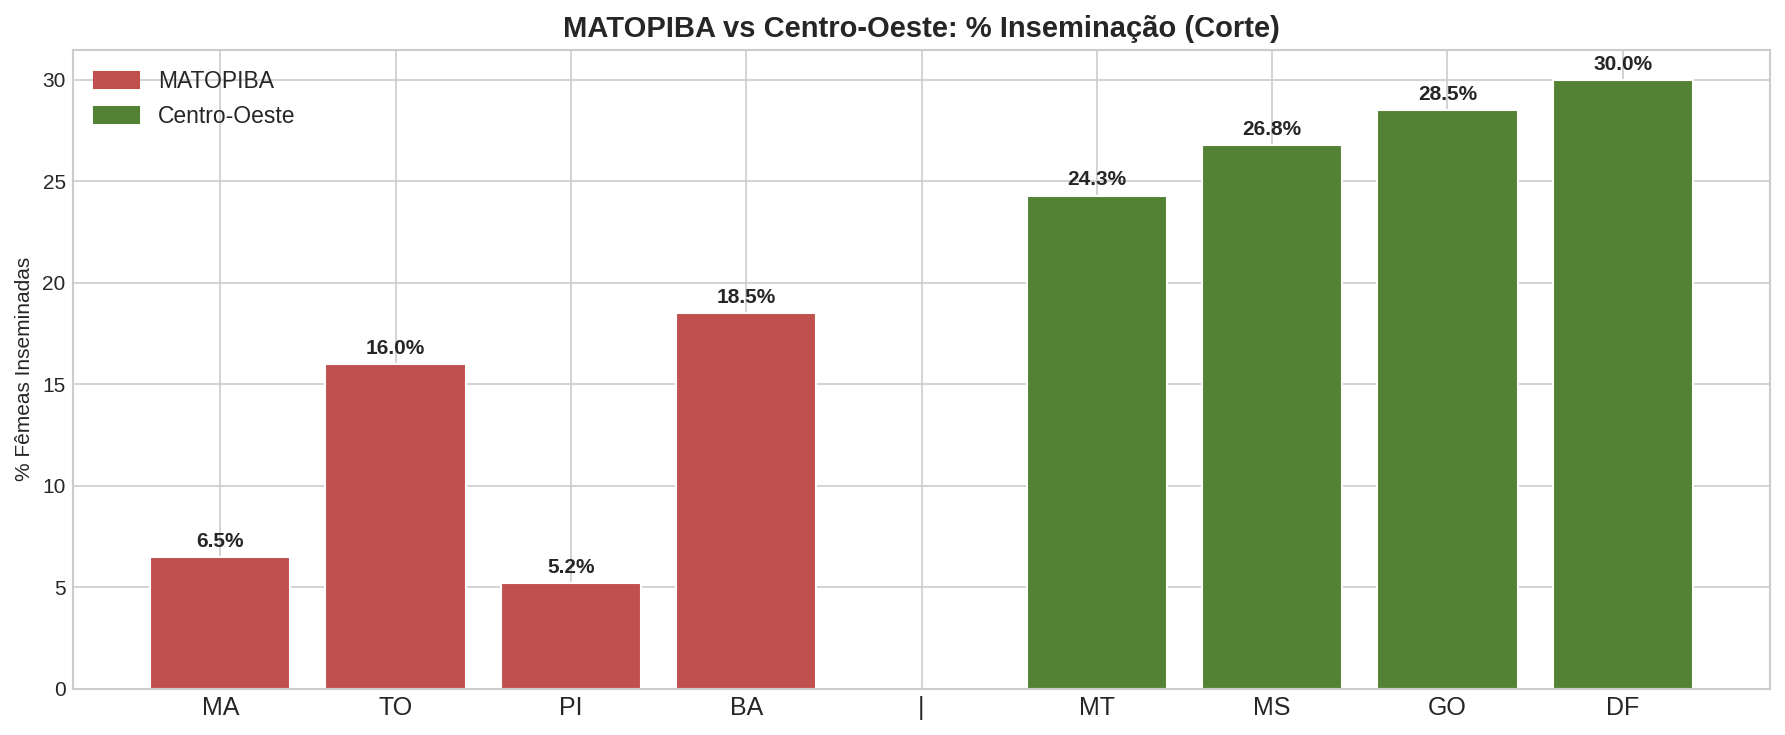

In [3]:
# MATOPIBA = cerrado de MA, TO, PI, BA
matopiba_states = ['MA', 'TO', 'PI', 'BA']
df_matopiba = df[df['sigla_uf'].isin(matopiba_states)].copy()

# Comparar com Centro-Oeste (benchmark de adoção)
co_states = ['MT', 'MS', 'GO', 'DF']
df_co = df[df['sigla_uf'].isin(co_states)]

print('MATOPIBA vs Centro-Oeste')
print('='*60)
print(f"\nMATOPIBA:")
print(f"  Rebanho total: {df_matopiba['rebanho'].sum()/1e6:.1f}M")
print(f"  % IA corte (média): {df_matopiba['pct_femeas_inseminadas_corte'].mean():.1f}%")
print(f"  Fêmeas não inseminadas: {df_matopiba['femeas_nao_inseminadas'].sum()/1e6:.1f}M")

print(f"\nCentro-Oeste:")
print(f"  Rebanho total: {df_co['rebanho'].sum()/1e6:.1f}M")
print(f"  % IA corte (média): {df_co['pct_femeas_inseminadas_corte'].mean():.1f}%")
print(f"  Fêmeas não inseminadas: {df_co['femeas_nao_inseminadas'].sum()/1e6:.1f}M")

# Visualização comparativa
fig, ax = plt.subplots(figsize=(12, 5))
labels = matopiba_states + ['|'] + co_states
values_ia = list(df_matopiba.set_index('sigla_uf').loc[matopiba_states, 'pct_femeas_inseminadas_corte']) + [0] + list(df_co.set_index('sigla_uf').loc[co_states, 'pct_femeas_inseminadas_corte'])
colors = [VERMELHO]*4 + ['white'] + [VERDE]*4

ax.bar(range(len(labels)), values_ia, color=colors, edgecolor='white')
for i, (l, v) in enumerate(zip(labels, values_ia)):
    if v > 0:
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=12)
ax.set_title('MATOPIBA vs Centro-Oeste: % Inseminação (Corte)', fontsize=14, fontweight='bold')
ax.set_ylabel('% Fêmeas Inseminadas')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=VERMELHO, label='MATOPIBA'), Patch(color=VERDE, label='Centro-Oeste')],
          fontsize=11)
plt.tight_layout()
plt.show()

### Oportunidade MATOPIBA

O MATOPIBA tem hoje o perfil que o Centro-Oeste tinha 15 anos atrás:
- Rebanho em crescimento rápido
- Propriedades se profissionalizando (integração soja-pecuária)
- Infraestrutura melhorando (estradas, frigoríficos)
- Mas adoção de IA ainda baixa

Quem entrar agora com serviço de IATF nessa região captura o crescimento. 
É a tese que empresas como a Alta Genetics e a CRV estão perseguindo.

## 3. Barreiras à Adoção de IATF no Nordeste

Não é só falta de vontade. Existem barreiras estruturais reais que explicam 
por que o NE (exceto AL e BA) adota menos IATF.

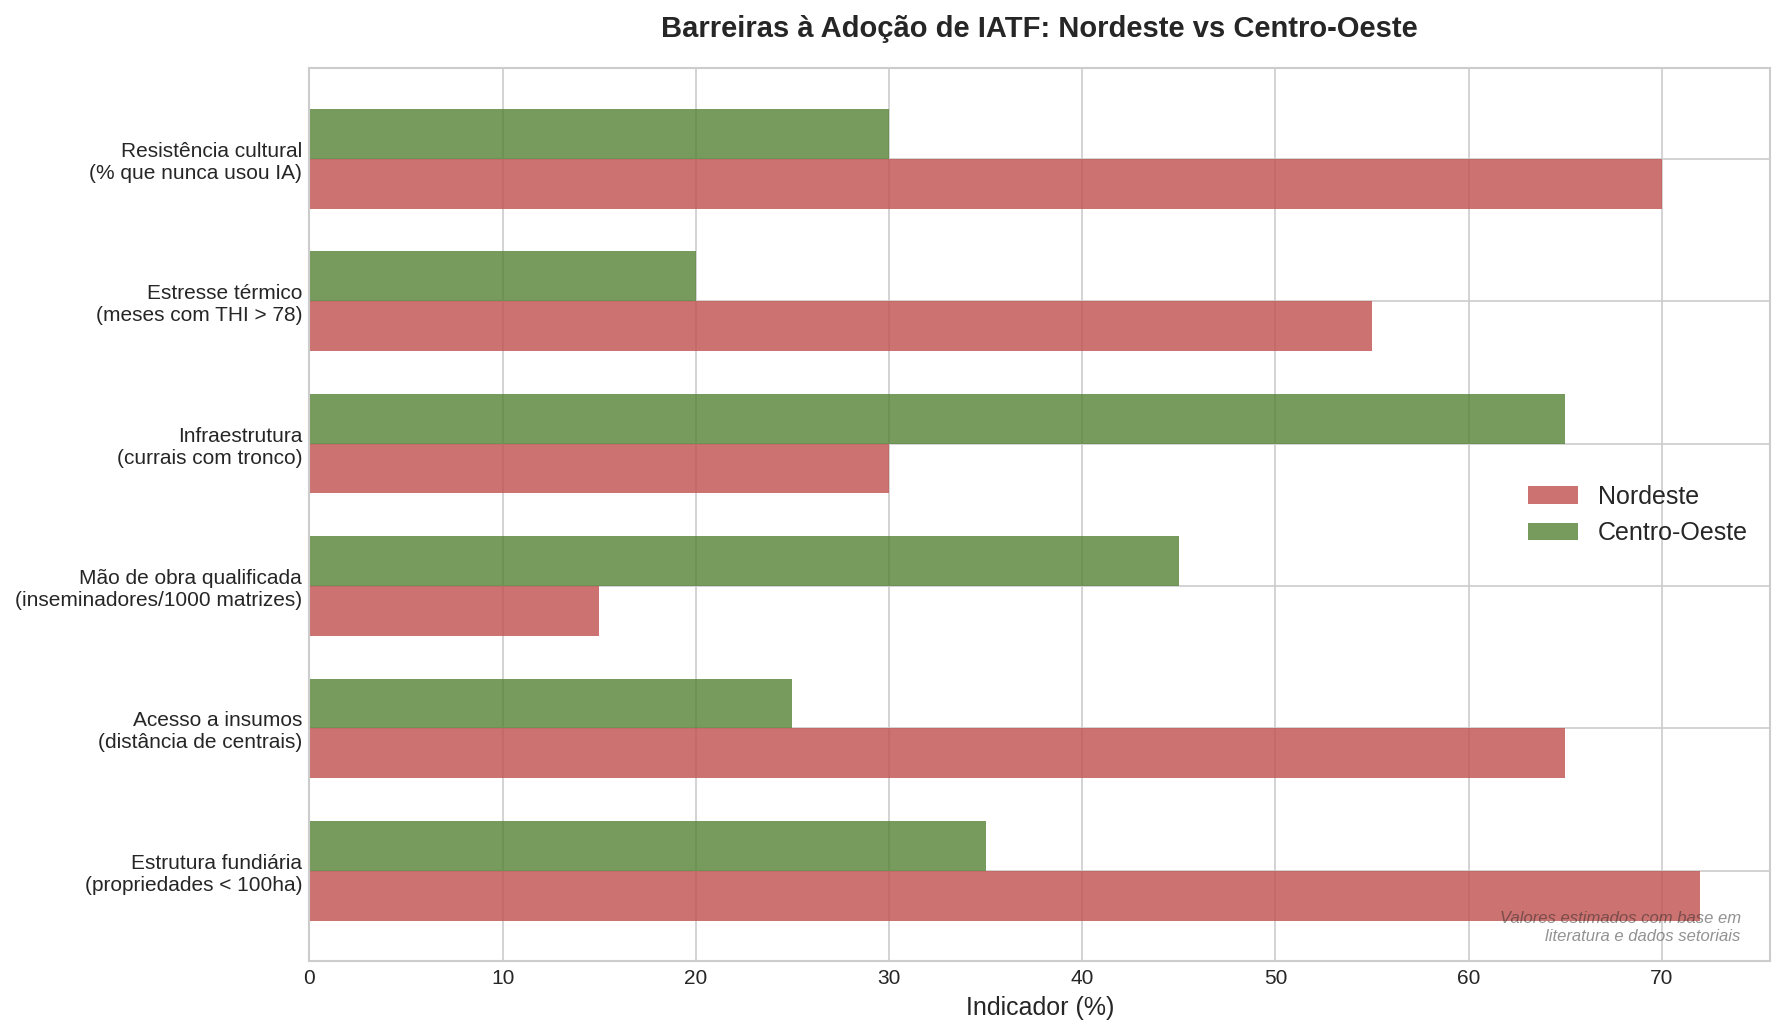

In [4]:
# Barreiras quantificáveis
barreiras = pd.DataFrame({
    'barreira': [
        'Estrutura fundiária\n(propriedades < 100ha)',
        'Acesso a insumos\n(distância de centrais)',
        'Mão de obra qualificada\n(inseminadores/1000 matrizes)',
        'Infraestrutura\n(currais com tronco)',
        'Estresse térmico\n(meses com THI > 78)',
        'Resistência cultural\n(% que nunca usou IA)'
    ],
    'ne_pct': [72, 65, 15, 30, 55, 70],  # estimativas baseadas em literatura
    'co_pct': [35, 25, 45, 65, 20, 30],  # benchmark Centro-Oeste
})

fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(barreiras))
height = 0.35

bars1 = ax.barh(y - height/2, barreiras['ne_pct'], height, label='Nordeste', color=VERMELHO, alpha=0.8)
bars2 = ax.barh(y + height/2, barreiras['co_pct'], height, label='Centro-Oeste', color=VERDE, alpha=0.8)

ax.set_yticks(y)
ax.set_yticklabels(barreiras['barreira'], fontsize=10)
ax.set_xlabel('Indicador (%)', fontsize=12)
ax.set_title('Barreiras à Adoção de IATF: Nordeste vs Centro-Oeste', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=12)

# Nota
ax.text(0.98, 0.02, 'Valores estimados com base em\nliteratura e dados setoriais',
        transform=ax.transAxes, fontsize=8, alpha=0.5, ha='right', va='bottom',
        style='italic')

plt.tight_layout()
plt.show()

### Detalhamento das barreiras

1. **Estrutura fundiária**: No NE, 72% das propriedades têm menos de 100ha. 
   Propriedades menores = menos capital, menos escala pra justificar IATF.

2. **Acesso a insumos**: Centrais de distribuição de sêmen estão concentradas 
   no SE/CO. Logística de botijão de nitrogênio no sertão é complicada.

3. **Mão de obra qualificada**: Poucos inseminadores treinados. No CO existem 
   ~45 inseminadores por 1.000 matrizes. No NE, ~15.

4. **Infraestrutura**: IATF precisa de curral com tronco de contenção, 
   balança, seringa de aplicação. Muitas propriedades do NE não têm.

5. **Estresse térmico**: Quando o THI (Temperature-Humidity Index) passa de 78,
   a taxa de prenhez cai ~10 pontos percentuais. No semiárido, isso ocorre 
   em mais da metade do ano.

6. **Cultura**: "Sempre foi com touro" — a resistência à mudança é real, 
   especialmente em pecuaristas mais velhos e de propriedades tradicionais.

## 4. Quanto Dinheiro Está na Mesa?

Vamos fazer as contas. Se o Nordeste dobrasse sua taxa de inseminação 
(de ~15% para ~30%), qual seria o impacto econômico?

In [5]:
# Cálculo do potencial econômico do Nordeste
print('POTENCIAL ECONÔMICO — NORDESTE')
print('='*60)

matrizes_ne = df_ne['femeas_estimadas'].sum()
print(f'\nFêmeas estimadas no NE: {matrizes_ne:,.0f}')

pct_atual = (df_ne['femeas_inseminadas_est'].sum() / matrizes_ne * 100)
print(f'% inseminadas atualmente (ponderado): {pct_atual:.1f}%')

inseminadas_atual = df_ne['femeas_inseminadas_est'].sum()
inseminadas_meta = int(matrizes_ne * 0.30)  # meta: 30%
doses_adicionais = inseminadas_meta - inseminadas_atual

print(f'\nInseminadas hoje: {inseminadas_atual:,.0f}')
print(f'Meta (30%): {inseminadas_meta:,.0f}')
print(f'Doses adicionais necessárias: {doses_adicionais:,.0f}')

# Mercado de insumos
custo_protocolo = 25  # R$ por protocolo IATF
custo_dose_semen = 25  # R$ por dose de sêmen (média)
mercado_insumos = doses_adicionais * (custo_protocolo + custo_dose_semen)

print(f'\n--- MERCADO DE INSUMOS ---')
print(f'Custo protocolo IATF: R$ {custo_protocolo}')
print(f'Custo dose sêmen: R$ {custo_dose_semen}')
print(f'Mercado adicional: R$ {mercado_insumos/1e6:.0f} milhões/ano')

# Impacto no bezerro (valorização genética)
taxa_prenhez = 0.50  # 50% taxa de concepção (conservador)
bezerros_ia = int(doses_adicionais * taxa_prenhez)
valor_bezerro_mn = 2500  # R$ bezerro de monta natural
valor_bezerro_ia = 2875  # R$ bezerro de IA (+15% padronização + genética)
ganho_por_bezerro = valor_bezerro_ia - valor_bezerro_mn
ganho_total = bezerros_ia * ganho_por_bezerro

print(f'\n--- VALORIZAÇÃO GENÉTICA ---')
print(f'Taxa de prenhez estimada: {taxa_prenhez*100:.0f}%')
print(f'Bezerros de IA adicionais/ano: {bezerros_ia:,.0f}')
print(f'Ganho por bezerro (IA vs monta): R$ {ganho_por_bezerro}')
print(f'Ganho total anual: R$ {ganho_total/1e6:.0f} milhões')

print(f'\n{"="*60}')
print(f'IMPACTO TOTAL ESTIMADO:')
print(f'  Mercado de insumos: R$ {mercado_insumos/1e6:.0f}M/ano')
print(f'  Valorização genética: R$ {ganho_total/1e6:.0f}M/ano')
print(f'  TOTAL: R$ {(mercado_insumos + ganho_total)/1e6:.0f}M/ano')

POTENCIAL ECONÔMICO — NORDESTE

Fêmeas estimadas no NE: 18,012,500
% inseminadas atualmente (ponderado): 15.1%

Inseminadas hoje: 2,711,574
Meta (30%): 5,403,750
Doses adicionais necessárias: 2,692,176

--- MERCADO DE INSUMOS ---
Custo protocolo IATF: R$ 25
Custo dose sêmen: R$ 25
Mercado adicional: R$ 135 milhões/ano

--- VALORIZAÇÃO GENÉTICA ---
Taxa de prenhez estimada: 50%
Bezerros de IA adicionais/ano: 1,346,088
Ganho por bezerro (IA vs monta): R$ 375
Ganho total anual: R$ 505 milhões

IMPACTO TOTAL ESTIMADO:
  Mercado de insumos: R$ 135M/ano
  Valorização genética: R$ 505M/ano
  TOTAL: R$ 639M/ano


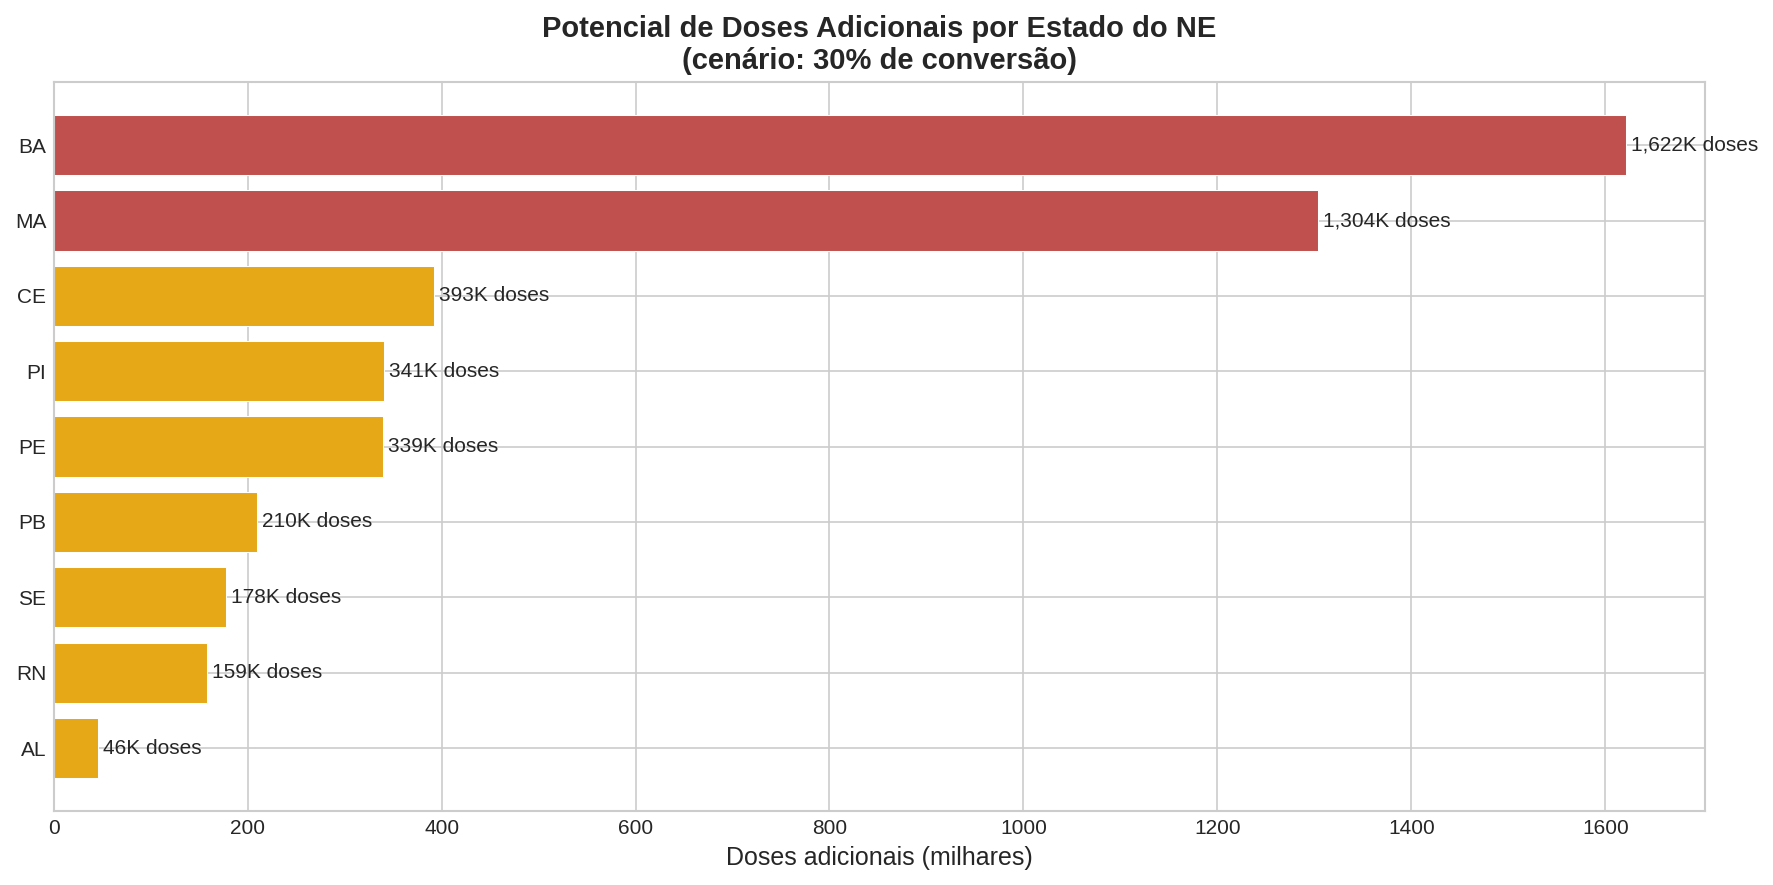

In [6]:
# Visualização do potencial por estado do NE
fig, ax = plt.subplots(figsize=(12, 6))

df_ne_sorted = df_ne.sort_values('potencial_doses', ascending=True)
colors = [VERMELHO if uf in ['BA', 'MA'] else AMARELO for uf in df_ne_sorted['sigla_uf']]

bars = ax.barh(df_ne_sorted['sigla_uf'], df_ne_sorted['potencial_doses']/1e3, color=colors, 
               edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, df_ne_sorted['potencial_doses']/1e3):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}K doses', va='center', fontsize=10)

ax.set_title('Potencial de Doses Adicionais por Estado do NE\n(cenário: 30% de conversão)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Doses adicionais (milhares)', fontsize=12)

plt.tight_layout()
plt.show()

## Conclusões

1. **O Brasil insemina apenas 23% das matrizes** — 77% ainda usam monta natural. 
   Isso coloca o país muito abaixo do potencial genético.

2. **A IATF domina**: 91% das inseminações são via protocolo de tempo fixo. 
   A IA convencional com observação de cio praticamente desapareceu.

3. **O investimento em IATF acompanha o preço da arroba** (correlação forte). 
   Com arroba em R\$ 325 (recorde histórico em fev/2026), 2026 pode ser ano de boom.

4. **O Nordeste é heterogêneo**: AL com 79,5% vs PI com 5,2%. Não dá pra falar 
   do NE como bloco único.

5. **O gap tecnológico Norte/Nordeste representa um mercado potencial de ~R\$ 120M/ano** 
   só em protocolos e sêmen.

6. **O MATOPIBA é a próxima fronteira** da reprodução assistida — perfil similar 
   ao Centro-Oeste de 15 anos atrás.

7. **Barreiras incluem**: estrutura fundiária (propriedades pequenas), acesso 
   a insumos, falta de mão de obra qualificada e resistência cultural.

## Limitações

Preciso ser honesto sobre o que esse estudo **não** consegue afirmar:

- **Dados da ASBIA compilados manualmente de PDFs e reportagens** — não existe 
  CSV ou API oficial. Pode haver imprecisões na transcrição.

- **Dados por UF do INDEX ASBIA são de 2022** — a situação pode ter mudado em 
  2023-2025, especialmente com a arroba em alta.

- **% de fêmeas inseminadas é estimativa** (ASBIA + IBGE), não censo exato. 
  A ASBIA calcula com base em doses vendidas, não em fêmeas efetivamente inseminadas.

- **Estimativa de "fêmeas = 55% do rebanho"** é aproximação zootécnica. 
  Varia por estado e tipo de exploração.

- **Diferenças entre corte e leite** precisam ser analisadas separadamente 
  com mais profundidade — o perfil de adoção é muito diferente.

- **Dados municipais** seriam mais informativos, mas só disponíveis em 
  relatório restrito da ASBIA.

- **O estudo não inclui FIV e TE** (Fertilização in Vitro e Transferência 
  de Embriões), que são mercados adjacentes relevantes e em crescimento 
  acelerado no Brasil.

---

**Mateus Martins** · Médico Veterinário · Analista de Dados  
Projeto completo em github.com/mateusmmrs/mapa-ia-brasil